# Project 3 — Unsupervised Learning: Customer Segmentation


**Objective:** Use distance-based algorithms (K-Means) and Principal Component Analysis (PCA) to discover hidden mathematical groupings in unlabeled retail transaction data, then translate those clusters into actionable business personas.

**Pipeline (IPO Architecture):**

1. **SCALE** — Standardize features (StandardScaler)
2. **COMPRESS** — Reduce dimensionality (PCA, 95% variance rule)
3. **CLUSTER** — Find optimal K using Elbow Method + Silhouette Score, then apply K-Means
4. **TRANSLATE** — Reverse-engineer centroids → human-readable Business Personas



## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

from kneed import KneeLocator   # Kneedle algorithm for elbow detection

# ── Plot aesthetics ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#4C72B0', '#C44E52', '#CCB974', '#55A868', '#8172B2']

print(" All libraries imported successfully.")

 All libraries imported successfully.


## 2. Load Dataset & First Look

In [2]:
df_raw= pd.read_excel("C:\\Users\\KS Technologies\\Desktop\\DecodeLab-DS Internship\\Product-Sales-Region.xlsx")

print(f"Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")

df_raw.head()


Shape: 1500 rows × 19 columns


,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,PaymentMethod,Promotion,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager
0,2023-02-23,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,Online,FREESHIP,0,REG100000,Cust 6583,43.34,2023-02-23,2023-02-27,Eric
1,2024-12-19,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,Gift Card,SAVE10,0,REG100001,Cust 2144,5.30,2024-12-19,2024-12-28,Sophie
2,2023-05-10,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,Online,WINTER15,0,REG100002,Cust 5998,20.46,2023-05-10,2023-05-19,Ryan
3,2025-02-26,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,Gift Card,FREESHIP,0,REG100003,Cust 7136,27.95,2025-02-26,2025-03-02,Cameron
4,2023-06-24,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,Online,SAVE10,0,REG100004,Cust 6506,5.73,2023-06-24,2023-06-27,Eric


In [3]:
print("=== Data Types ===")
print(df_raw.dtypes)

print("=== Missing Values ===")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])


=== Data Types ===
Date             datetime64[ns]
Region                   object
Product                  object
Quantity                  int64
UnitPrice               float64
StoreLocation            object
CustomerType             object
Discount                float64
Salesperson              object
TotalPrice              float64
PaymentMethod            object
Promotion                object
Returned                  int64
OrderID                  object
CustomerName             object
ShippingCost            float64
OrderDate        datetime64[ns]
DeliveryDate     datetime64[ns]
RegionManager            object
dtype: object
=== Missing Values ===
Promotion    370
dtype: int64


In [4]:
df_raw.describe()


,Date,Quantity,UnitPrice,Discount,TotalPrice,Returned,ShippingCost,OrderDate,DeliveryDate
count,1500,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500,1500
mean,2024-04-07 21:35:02.400000256,10.410667,298.826947,0.073133,2919.994952,0.248000,27.507293,2024-04-07 21:35:02.400000256,2024-04-13 22:36:28.799999744
min,2023-01-01 00:00:00,1.000000,5.520000,0.000000,6.970000,0.000000,5.010000,2023-01-01 00:00:00,2023-01-08 00:00:00
25%,2023-08-20 00:00:00,5.000000,151.020000,0.000000,867.136250,0.000000,16.700000,2023-08-20 00:00:00,2023-08-25 12:00:00
50%,2024-04-08 12:00:00,11.000000,294.740000,0.050000,2174.724000,0.000000,27.100000,2024-04-08 12:00:00,2024-04-15 12:00:00
75%,2024-12-07 06:00:00,15.000000,446.702500,0.100000,4414.723500,0.000000,38.635000,2024-12-07 06:00:00,2024-12-13 06:00:00
max,2025-06-30 00:00:00,20.000000,599.720000,0.150000,11077.000000,1.000000,49.980000,2025-06-30 00:00:00,2025-07-10 00:00:00
std,NaN,5.735732,169.100075,0.055979,2522.789977,0.431996,13.093453,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

We inspect distributions, correlations and category breakdowns before engineering features for clustering.


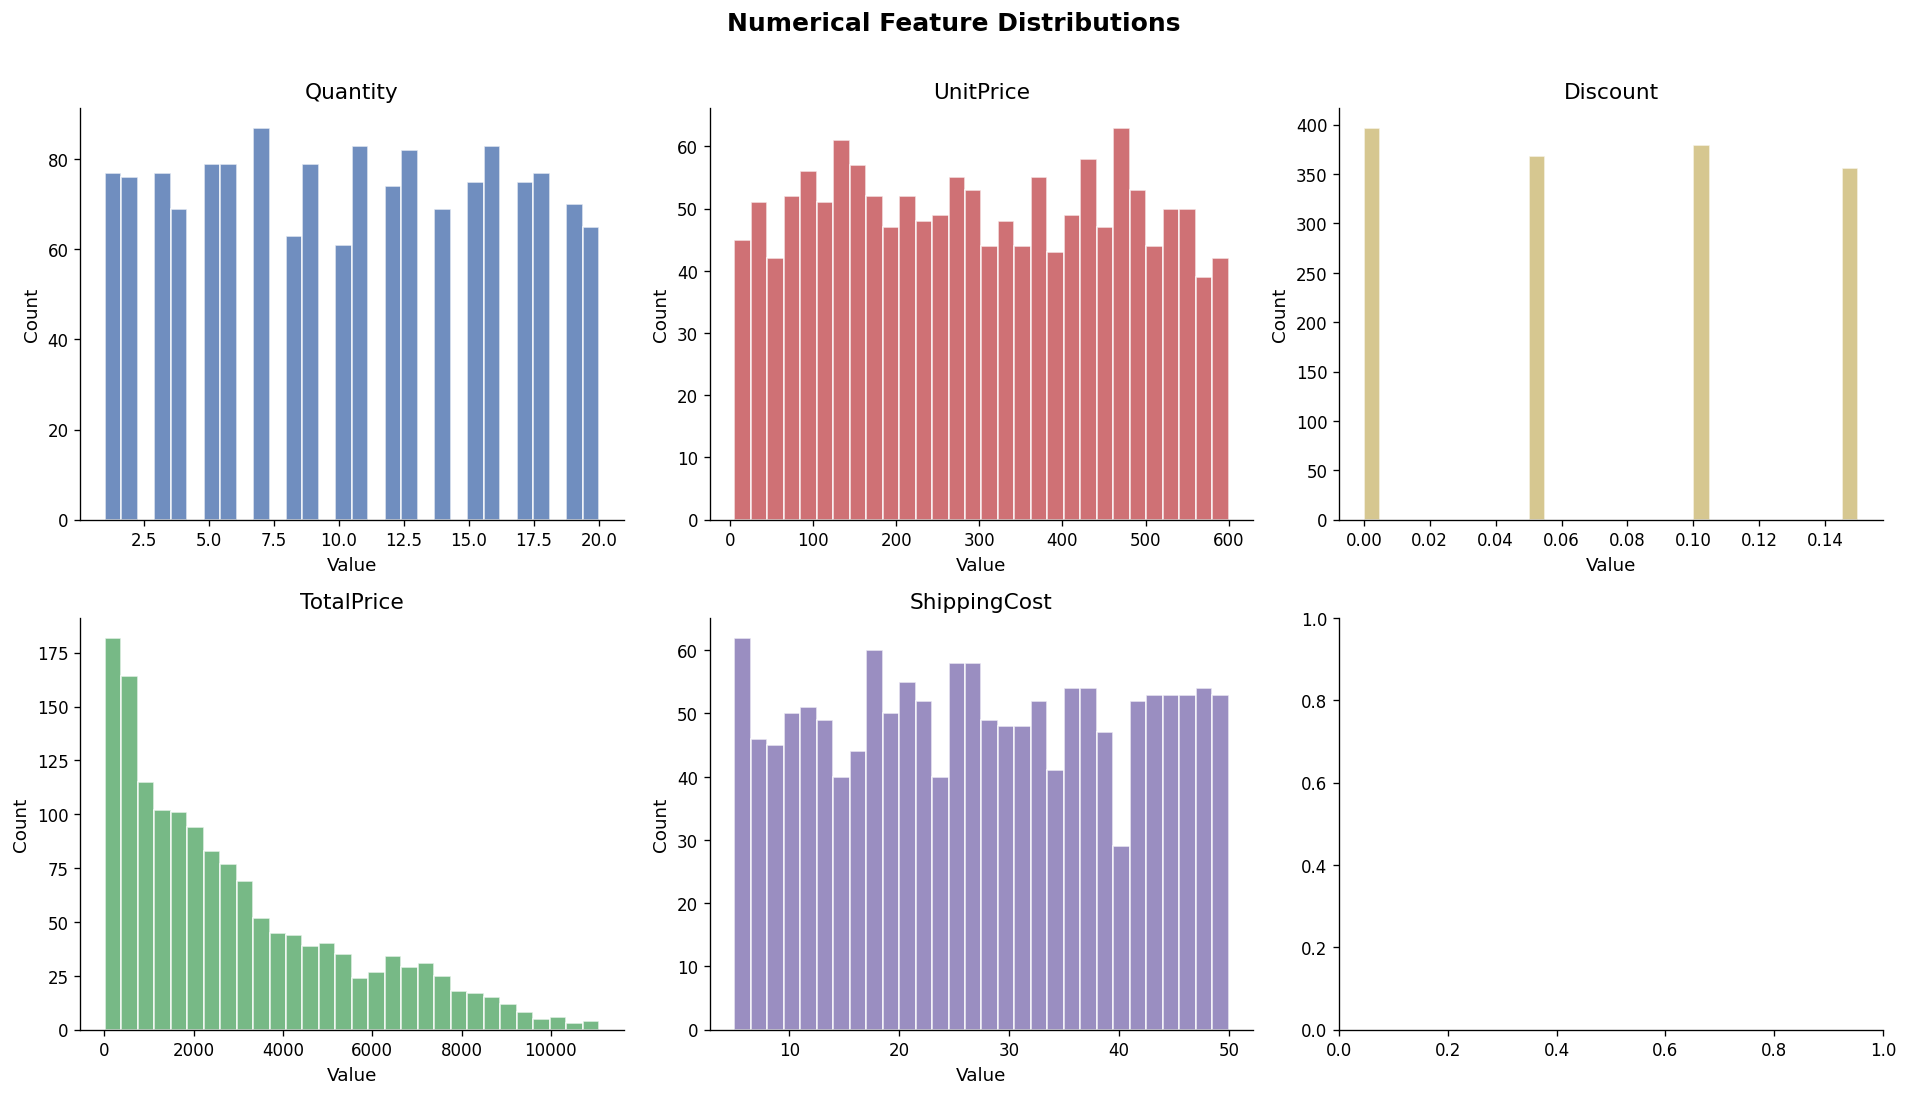

Figure saved.


In [40]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Numerical Feature Distributions", fontsize=15, fontweight='bold', y=1.01)

num_cols = ['Quantity', 'UnitPrice', 'Discount', 'TotalPrice', 'ShippingCost', 'Returned']
colors   = PALETTE[:6]

for ax, col, color in zip(axes.flat, num_cols, colors):
    ax.hist(df_raw[col], bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()
print("Figure saved.")


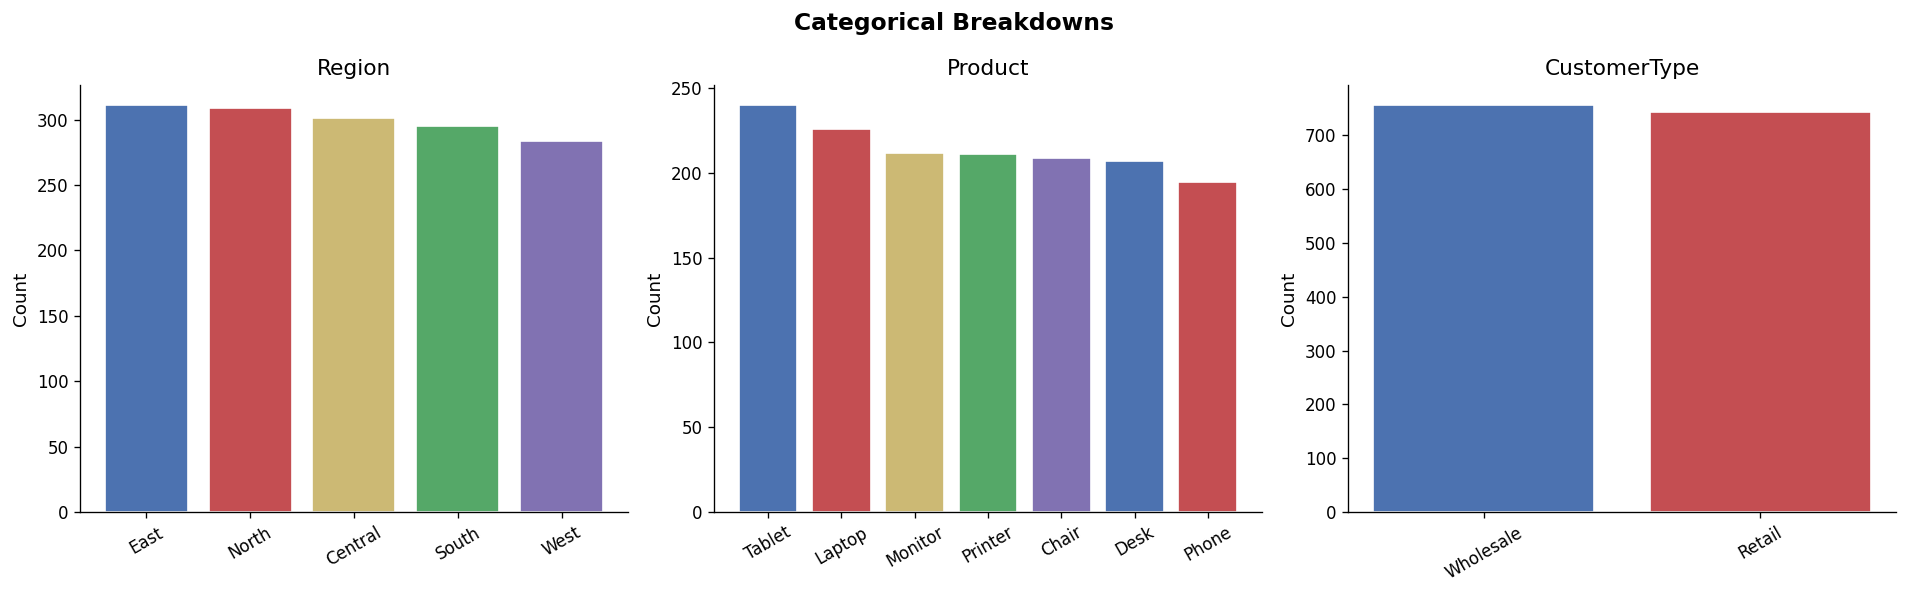

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Categorical Breakdowns", fontsize=14, fontweight='bold')

cat_cols = ['Region', 'Product', 'CustomerType']
for ax, col in zip(axes, cat_cols):
    vc = df_raw[col].value_counts()
    ax.bar(vc.index, vc.values, color=PALETTE[:len(vc)], edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_categoricals.png', bbox_inches='tight')
plt.show()


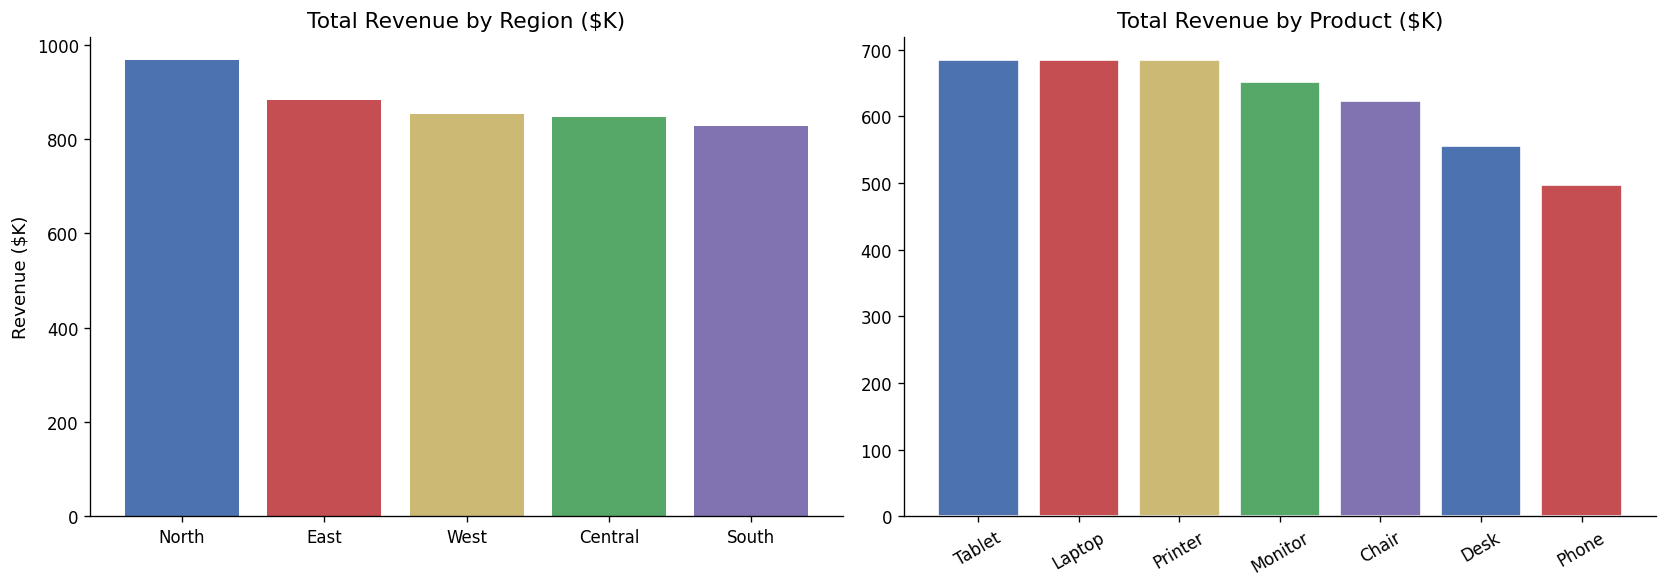

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by region
rev_region = df_raw.groupby('Region')['TotalPrice'].sum().sort_values(ascending=False)
axes[0].bar(rev_region.index, rev_region.values / 1e3, color=PALETTE)
axes[0].set_title("Total Revenue by Region ($K)")
axes[0].set_ylabel("Revenue ($K)")

# Revenue by product
rev_prod = df_raw.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
axes[1].bar(rev_prod.index, rev_prod.values / 1e3, color=PALETTE[:7], edgecolor='white')
axes[1].set_title("Total Revenue by Product ($K)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('eda_revenue.png', bbox_inches='tight')
plt.show()


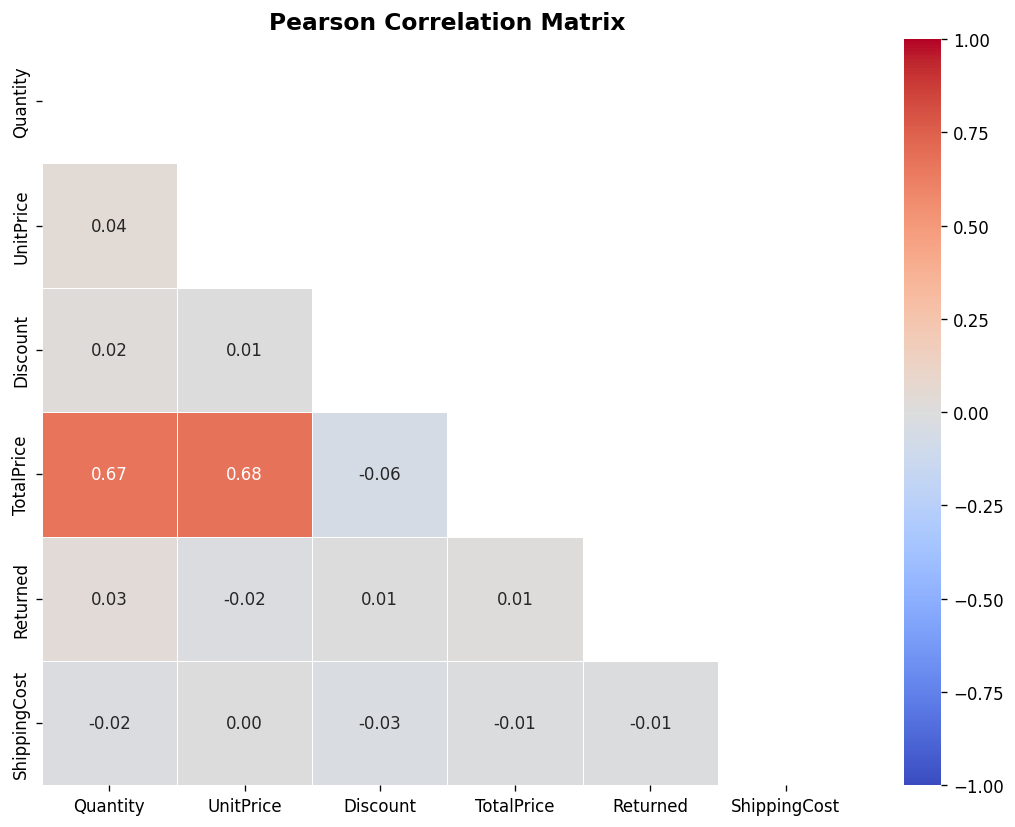

In [43]:
# Correlation heat-map (numeric features only)
num_df = df_raw.select_dtypes(include='number')
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()


## 4. Feature Engineering

We aggregate raw transactional rows into **customer-level profiles**.  
Each unique `CustomerName` becomes one record with RFM-style and behavioural metrics.


In [44]:
# ── Date features ────────────────────────────────────────────────────────────
df = df_raw.copy()
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)

df['DeliveryDays'] = (df['DeliveryDate'] - df['OrderDate']).dt.days

# ── Customer-level aggregation ────────────────────────────────────────────────
cust = df.groupby('CustomerName').agg(
    Recency          = ('Date', lambda x: (snapshot_date - x.max()).days),
    Frequency        = ('OrderID', 'count'),
    Monetary         = ('TotalPrice', 'sum'),
    AvgOrderValue    = ('TotalPrice', 'mean'),
    AvgDiscount      = ('Discount', 'mean'),
    AvgShipping      = ('ShippingCost', 'mean'),
    AvgQty           = ('Quantity', 'mean'),
    ReturnRate       = ('Returned', 'mean'),
    AvgDeliveryDays  = ('DeliveryDays', 'mean'),
    UniqueProducts   = ('Product', 'nunique'),
    UniqueRegions    = ('Region', 'nunique'),
).reset_index()

# ── Encode dominant categorical preferences ───────────────────────────────────
preferred_payment = (df.groupby(['CustomerName', 'PaymentMethod'])
                       .size().reset_index(name='cnt')
                       .sort_values('cnt', ascending=False)
                       .drop_duplicates('CustomerName')
                       .set_index('CustomerName')['PaymentMethod'])

preferred_product = (df.groupby(['CustomerName', 'Product'])
                       .size().reset_index(name='cnt')
                       .sort_values('cnt', ascending=False)
                       .drop_duplicates('CustomerName')
                       .set_index('CustomerName')['Product'])

preferred_region  = (df.groupby(['CustomerName', 'Region'])
                       .size().reset_index(name='cnt')
                       .sort_values('cnt', ascending=False)
                       .drop_duplicates('CustomerName')
                       .set_index('CustomerName')['Region'])

le_pay  = LabelEncoder()
le_prod = LabelEncoder()
le_reg  = LabelEncoder()

cust = cust.set_index('CustomerName')
cust['PrefPayment'] = le_pay.fit_transform(preferred_payment.reindex(cust.index).fillna('Cash'))
cust['PrefProduct'] = le_prod.fit_transform(preferred_product.reindex(cust.index).fillna('Laptop'))
cust['PrefRegion']  = le_reg.fit_transform(preferred_region.reindex(cust.index).fillna('East'))

print(f"Customer profiles shape: {cust.shape}")
cust.head()


Customer profiles shape: (1371, 14)


,Recency,Frequency,Monetary,AvgOrderValue,AvgDiscount,AvgShipping,AvgQty,ReturnRate,AvgDeliveryDays,UniqueProducts,UniqueRegions,PrefPayment,PrefProduct,PrefRegion
CustomerName,,,,,,,,,,,,,,
Cust 1003,1,1,289.728,289.728,0.10,44.97,2.0,0.0,5.0,1,1,3,0,2
Cust 1007,338,1,366.360,366.360,0.00,49.09,6.0,1.0,8.0,1,1,2,6,4
Cust 1015,547,1,1462.020,1462.020,0.00,20.64,7.0,0.0,7.0,1,1,0,3,3
Cust 1023,339,1,3747.484,3747.484,0.05,11.49,8.0,0.0,9.0,1,1,1,2,3
Cust 1031,881,1,1692.320,1692.320,0.00,48.13,7.0,0.0,8.0,1,1,4,4,0


## 5. Phase 1 — Standardisation (SCALE)

K-Means uses Euclidean distance, so features on different scales would dominate the clustering.  
`StandardScaler` maps every feature to zero-mean, unit-variance space — giving **equal mathematical voting power** to all dimensions.

Formula: `z = (x − μ) / σ`


In [45]:
feature_cols = [
    'Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
    'AvgDiscount', 'AvgShipping', 'AvgQty', 'ReturnRate',
    'AvgDeliveryDays', 'UniqueProducts', 'UniqueRegions',
    'PrefPayment', 'PrefProduct', 'PrefRegion'
]

X = cust[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=cust.index)

print(f"Features after scaling: {X_scaled.shape[1]}")
print(f"Customers: {X_scaled.shape[0]}")
print()
print("Post-scaling statistics (should be ~0 mean, ~1 std):")
pd.DataFrame(X_scaled, columns=feature_cols).describe().loc[['mean','std']].round(4)


Features after scaling: 14
Customers: 1371

Post-scaling statistics (should be ~0 mean, ~1 std):


,Recency,Frequency,Monetary,AvgOrderValue,AvgDiscount,AvgShipping,AvgQty,ReturnRate,AvgDeliveryDays,UniqueProducts,UniqueRegions,PrefPayment,PrefProduct,PrefRegion
mean,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000
std,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004


## 6. Phase 2 — Dimensionality Reduction (PCA)

With 14 features the data lives in high-dimensional space where Euclidean distance degrades (the *curse of dimensionality*).  
PCA finds **orthogonal axes of maximum variance** (Principal Components) and projects the data onto a lower-dimensional surface while preserving as much information as possible.

**95% rule:** We keep the minimum number of components whose **cumulative explained variance ≥ 0.95**.


In [46]:
# ── Full PCA to inspect explained variance ───────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

evr        = pca_full.explained_variance_ratio_
cum_evr    = np.cumsum(evr)
n_comp_95  = int(np.argmax(cum_evr >= 0.95)) + 1
n_comp_viz = 2   # for 2-D scatter visualisation

print(f"Components to reach 95% variance: {n_comp_95}")
print(f"Individual explained variance: {np.round(evr[:n_comp_95+2], 4)}")
print(f"Cumulative at {n_comp_95} components: {cum_evr[n_comp_95-1]:.4f}")


Components to reach 95% variance: 11
Individual explained variance: [0.2171 0.1721 0.0787 0.0748 0.0718 0.071  0.0675 0.0665 0.0653 0.0625
 0.0301 0.0144 0.0068]
Cumulative at 11 components: 0.9774


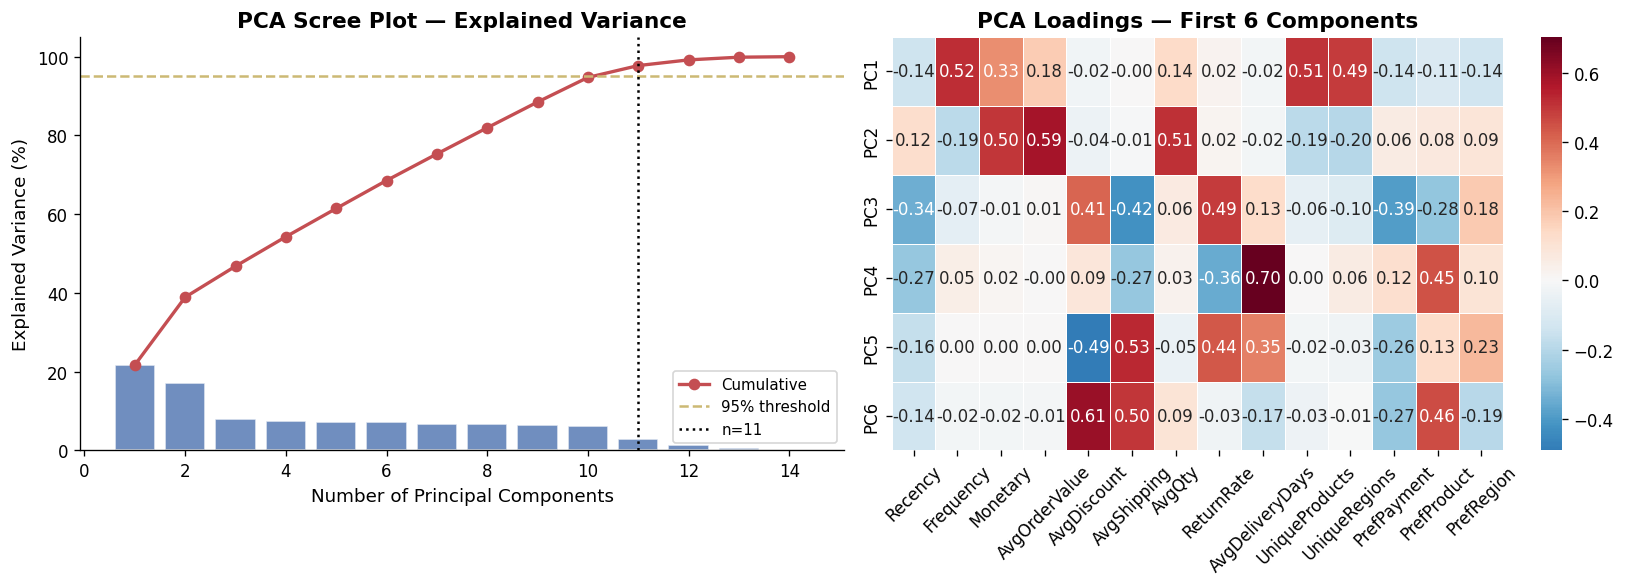

 Retaining 11 components (≥95% variance explained).


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scree plot ---
axes[0].bar(range(1, len(evr)+1), evr*100, color='#4C72B0', alpha=0.8, edgecolor='white')
axes[0].plot(range(1, len(evr)+1), cum_evr*100, 'o-', color='#C44E52', linewidth=2, label='Cumulative')
axes[0].axhline(95, linestyle='--', color='#CCB974', linewidth=1.5, label='95% threshold')
axes[0].axvline(n_comp_95, linestyle=':', color='black', linewidth=1.5, label=f'n={n_comp_95}')
axes[0].set_xlabel("Number of Principal Components")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("PCA Scree Plot — Explained Variance", fontweight='bold')
axes[0].legend(fontsize=9)

# --- Component loadings heat-map (first 6 PCs) ---
n_show = min(6, n_comp_95)
loadings = pd.DataFrame(
    pca_full.components_[:n_show],
    columns=feature_cols,
    index=[f'PC{i+1}' for i in range(n_show)]
)
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            linewidths=0.3, ax=axes[1], center=0)
axes[1].set_title(f"PCA Loadings — First {n_show} Components", fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('pca_analysis.png', bbox_inches='tight')
plt.show()
print(f" Retaining {n_comp_95} components (≥95% variance explained).")


In [48]:
# Apply PCA with optimal and 2-D versions
pca_opt = PCA(n_components=n_comp_95, random_state=42)
X_pca   = pca_opt.fit_transform(X_scaled)

pca_2d  = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Reduced feature space: {X_pca.shape}  (used for clustering)")
print(f"2-D space: {X_pca_2d.shape}  (used for visualisation)")


Reduced feature space: (1371, 11)  (used for clustering)
2-D space: (1371, 2)  (used for visualisation)


## 7. Phase 3 — Finding Optimal K

K-Means requires us to specify K up front.  We use **two diagnostic gatekeepers** to mathematically prove the best value:

In [49]:
K_RANGE = range(2, 11)

wcss        = []
sil_scores  = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_pca)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    print(f"K={k:2d}  WCSS={km.inertia_:,.1f}  Silhouette={sil_scores[-1]:.4f}")


K= 2  WCSS=15,041.9  Silhouette=0.3757
K= 3  WCSS=12,797.9  Silhouette=0.1835
K= 4  WCSS=11,833.2  Silhouette=0.1639
K= 5  WCSS=11,251.8  Silhouette=0.1306
K= 6  WCSS=10,856.6  Silhouette=0.1223
K= 7  WCSS=10,508.7  Silhouette=0.1173
K= 8  WCSS=10,203.2  Silhouette=0.1198
K= 9  WCSS=9,960.4  Silhouette=0.1154
K=10  WCSS=9,754.6  Silhouette=0.1128


In [19]:
# Elbow detection via Kneedle algorithm
kl = KneeLocator(list(K_RANGE), wcss, curve='convex', direction='decreasing', interp_method='polynomial')
elbow_k = kl.knee
best_sil_k = list(K_RANGE)[np.argmax(sil_scores)]

print(f"Elbow Method    → optimal K = {elbow_k}")
print(f"Silhouette Score → optimal K = {best_sil_k}  (score: {max(sil_scores):.4f})")
OPTIMAL_K = best_sil_k if best_sil_k == elbow_k else best_sil_k
print(f"\nChosen K = {OPTIMAL_K} (highest silhouette score)")


Elbow Method    → optimal K = 4
Silhouette Score → optimal K = 2  (score: 0.3757)

Chosen K = 2 (highest silhouette score)


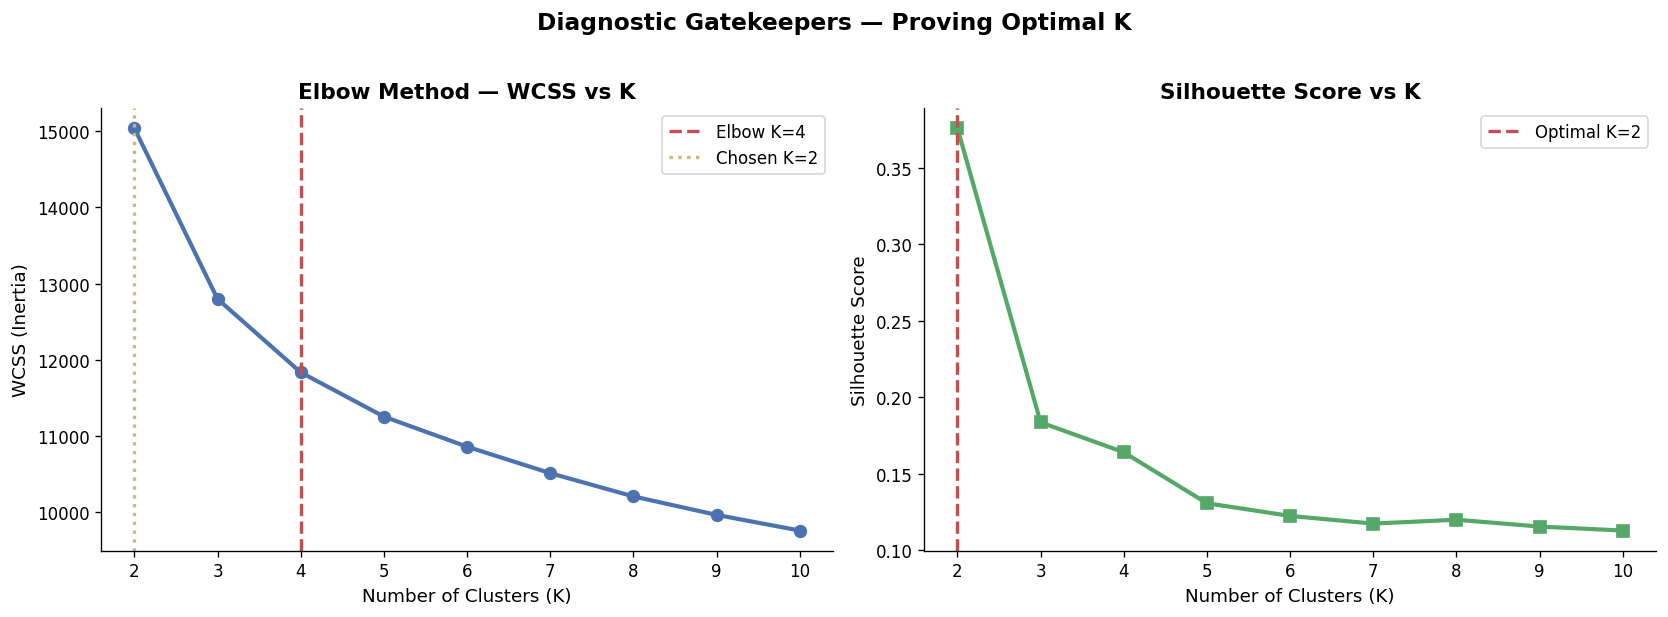

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Elbow plot ---
axes[0].plot(list(K_RANGE), wcss, 'o-', color='#4C72B0', linewidth=2.5, markersize=7)
if elbow_k:
    axes[0].axvline(elbow_k, linestyle='--', color='#C44E52', linewidth=2, label=f'Elbow K={elbow_k}')
axes[0].axvline(OPTIMAL_K, linestyle=':', color='#CCB974', linewidth=2, label=f'Chosen K={OPTIMAL_K}')
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].set_title("Elbow Method — WCSS vs K", fontweight='bold')
axes[0].legend()

# --- Silhouette plot ---
axes[1].plot(list(K_RANGE), sil_scores, 's-', color='#55A868', linewidth=2.5, markersize=7)
axes[1].axvline(OPTIMAL_K, linestyle='--', color='#C44E52', linewidth=2, label=f'Optimal K={OPTIMAL_K}')
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs K", fontweight='bold')
axes[1].legend()

plt.suptitle("Diagnostic Gatekeepers — Proving Optimal K", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('optimal_k.png', bbox_inches='tight')
plt.show()


## 8. Final K-Means Clustering

We now fit K-Means with the proven optimal K on the PCA-reduced space.


In [21]:
km_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=50, random_state=42)
cust['Cluster'] = km_final.fit_predict(X_pca)

print("Cluster distribution:")
print(cust['Cluster'].value_counts().sort_index())
print(f"\nFinal WCSS: {km_final.inertia_:,.2f}")
print(f"Final Silhouette Score: {silhouette_score(X_pca, cust['Cluster']):.4f}")


Cluster distribution:
Cluster
0    1255
1     116
Name: count, dtype: int64

Final WCSS: 15,041.92
Final Silhouette Score: 0.3757


## 9. Cluster Visualisation

### 9.1 — 2-D PCA Scatter (Decision Space)


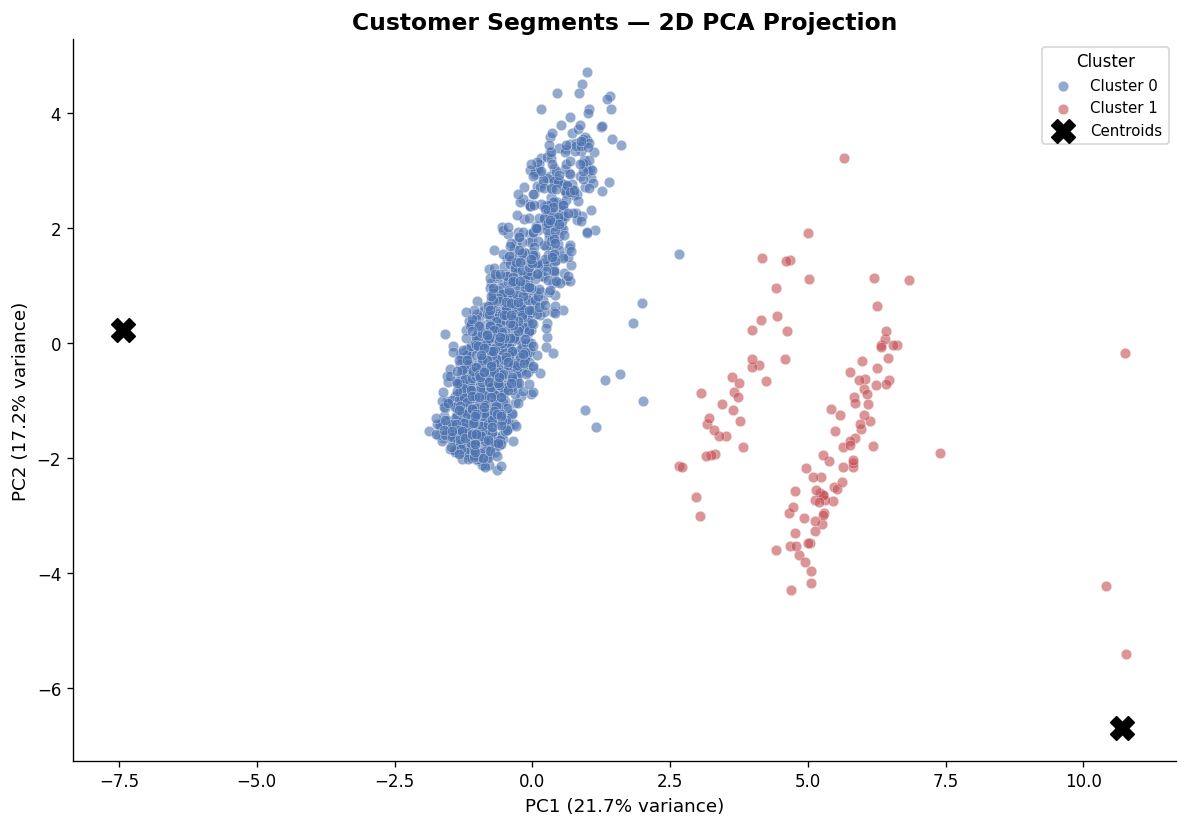

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))

for c in range(OPTIMAL_K):
    mask = cust['Cluster'] == c
    ax.scatter(X_pca_2d[mask.values, 0], X_pca_2d[mask.values, 1],
               color=PALETTE[c], alpha=0.6, s=40, edgecolors='white', linewidths=0.3,
               label=f'Cluster {c}')

# Plot centroids projected to 2D
centroids_2d = pca_2d.transform(scaler.transform(
    pd.DataFrame(pca_opt.inverse_transform(km_final.cluster_centers_), columns=feature_cols)
))
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           color='black', marker='X', s=200, zorder=5, label='Centroids')

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("Customer Segments — 2D PCA Projection", fontsize=14, fontweight='bold')
ax.legend(title='Cluster', fontsize=9)
plt.tight_layout()
plt.savefig('cluster_scatter.png', bbox_inches='tight')
plt.show()


### 9.2 — Silhouette Plot

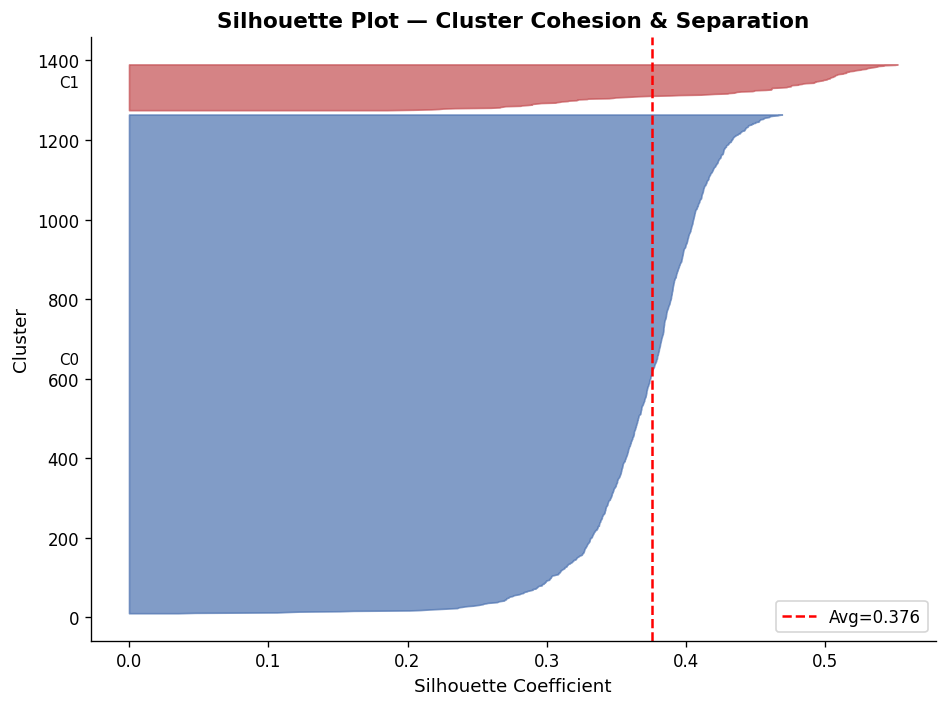

In [23]:
from sklearn.metrics import silhouette_samples

sil_vals = silhouette_samples(X_pca, cust['Cluster'].values)
fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10
for c in range(OPTIMAL_K):
    c_sil = np.sort(sil_vals[cust['Cluster'].values == c])
    size_c = len(c_sil)
    y_upper = y_lower + size_c
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=PALETTE[c], edgecolor=PALETTE[c], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_c, f'C{c}', fontsize=9)
    y_lower = y_upper + 10

avg_sil = np.mean(sil_vals)
ax.axvline(avg_sil, color='red', linestyle='--', linewidth=1.5, label=f'Avg={avg_sil:.3f}')
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Silhouette Plot — Cluster Cohesion & Separation", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_plot.png', bbox_inches='tight')
plt.show()


### 9.3 — Radar / Spider Chart of Cluster Profiles

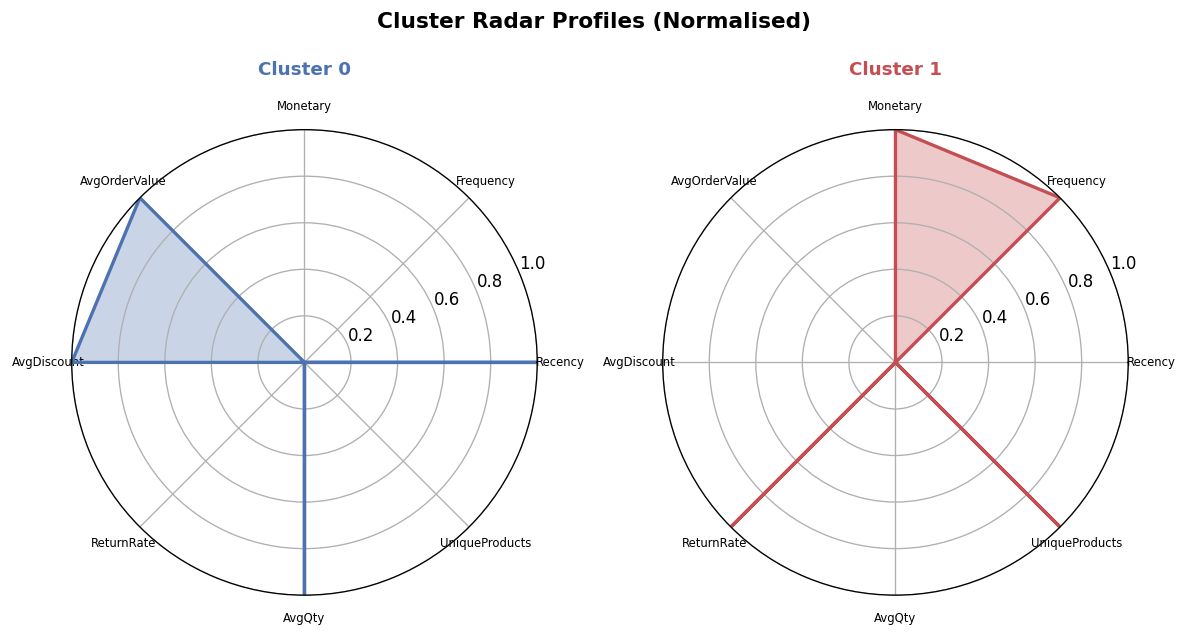

In [24]:
radar_features = ['Recency','Frequency','Monetary','AvgOrderValue','AvgDiscount',
                  'ReturnRate','AvgQty','UniqueProducts']

cluster_means = cust.groupby('Cluster')[radar_features].mean()
# Min-max normalise for radar
norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min() + 1e-9)

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(5*OPTIMAL_K, 5), subplot_kw=dict(polar=True))
if OPTIMAL_K == 1:
    axes = [axes]

for c, ax in enumerate(axes):
    vals = norm.loc[c].tolist()
    vals += vals[:1]
    ax.fill(angles, vals, color=PALETTE[c], alpha=0.3)
    ax.plot(angles, vals, color=PALETTE[c], linewidth=2)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_features, fontsize=7)
    ax.set_title(f"Cluster {c}", fontsize=11, fontweight='bold', pad=15, color=PALETTE[c])
    ax.set_ylim(0, 1)

plt.suptitle("Cluster Radar Profiles (Normalised)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('radar_profiles.png', bbox_inches='tight')
plt.show()


## 10. Phase 4 — Reverse-Engineering Centroids to Original Space

Centroids exist in PCA-space. We **inverse transform** through PCA then through StandardScaler to get interpretable, human-centric metrics.


In [25]:
# Inverse transform: PCA-space → scaled space → original space
centroids_pca    = km_final.cluster_centers_
centroids_scaled = pca_opt.inverse_transform(centroids_pca)
centroids_orig   = scaler.inverse_transform(centroids_scaled)

centroid_df = pd.DataFrame(centroids_orig, columns=feature_cols)
centroid_df.index.name = 'Cluster'
centroid_df = centroid_df.round(2)
centroid_df


,Recency,Frequency,Monetary,AvgOrderValue,AvgDiscount,AvgShipping,AvgQty,ReturnRate,AvgDeliveryDays,UniqueProducts,UniqueRegions,PrefPayment,PrefProduct,PrefRegion
Cluster,,,,,,,,,,,,,,
0,448.11,1.01,2954.26,2928.35,0.07,27.44,10.46,0.24,6.06,1.00,1.00,2.01,3.01,2.00
1,263.85,2.04,5796.53,2920.03,0.07,27.83,10.15,0.26,5.87,1.89,1.83,1.11,2.01,1.08


In [26]:
# Also show key RFM stats per cluster from real data
summary = cust.groupby('Cluster')[['Recency','Frequency','Monetary',
                                    'AvgOrderValue','AvgDiscount','ReturnRate',
                                    'UniqueProducts']].mean().round(2)
summary['Count'] = cust.groupby('Cluster').size()
summary['Count%'] = (summary['Count'] / len(cust) * 100).round(1)
print("=== Cluster Summary (Real Data Means) ===")
summary


=== Cluster Summary (Real Data Means) ===


,Recency,Frequency,Monetary,AvgOrderValue,AvgDiscount,ReturnRate,UniqueProducts,Count,Count%
Cluster,,,,,,,,,
0,448.07,1.01,2949.94,2932.78,0.07,0.25,1.00,1255,91.5
1,264.34,2.04,5843.29,2872.09,0.07,0.26,1.91,116,8.5


## 11. Feature Distributions per Cluster

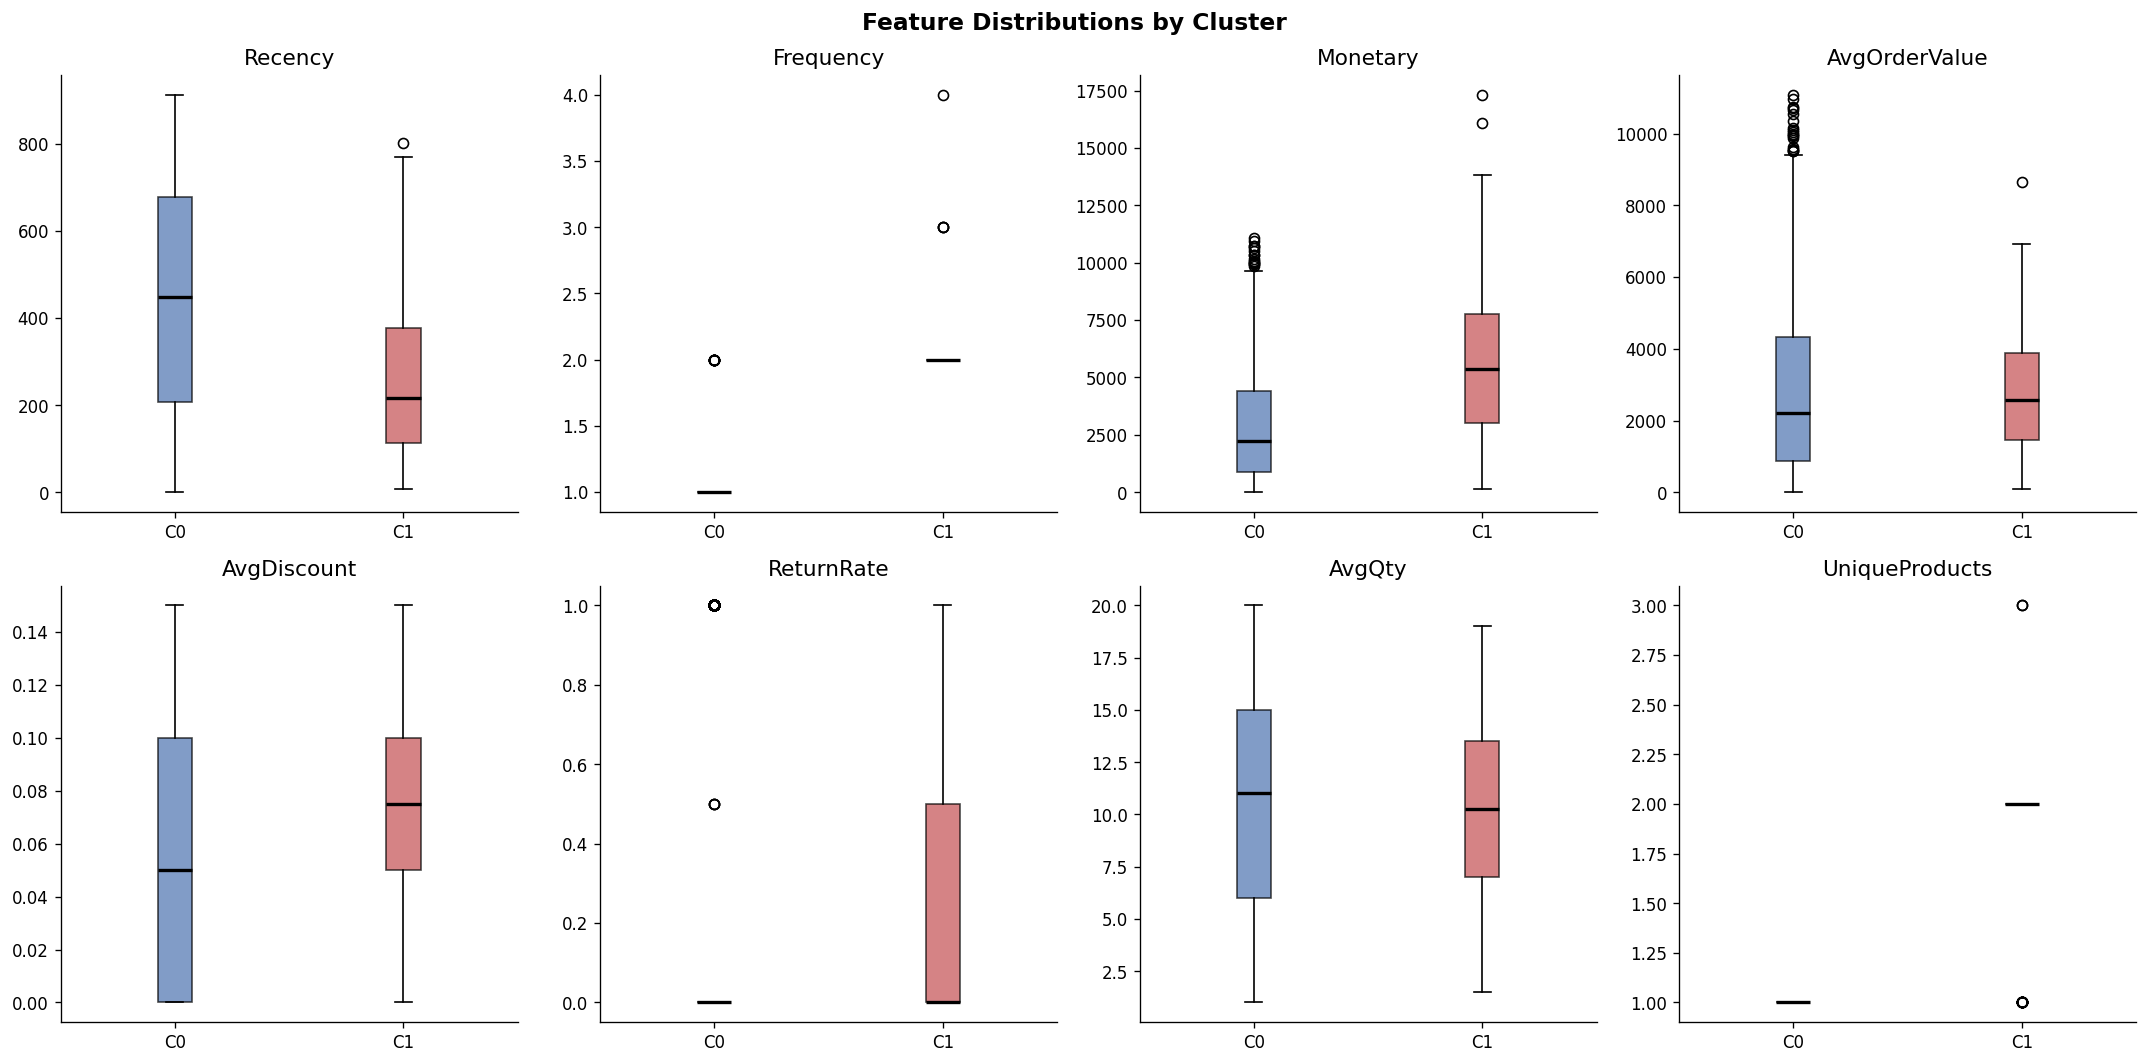

In [27]:
plot_feats = ['Recency','Frequency','Monetary','AvgOrderValue',
              'AvgDiscount','ReturnRate','AvgQty','UniqueProducts']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Feature Distributions by Cluster", fontsize=14, fontweight='bold')

for ax, feat in zip(axes.flat, plot_feats):
    data = [cust[cust['Cluster']==c][feat].values for c in range(OPTIMAL_K)]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(feat)
    ax.set_xticklabels([f'C{c}' for c in range(OPTIMAL_K)])

plt.tight_layout()
plt.savefig('boxplots.png', bbox_inches='tight')
plt.show()


## 12. The Strategic Persona Matrix
We reverse-engineer each cluster centroid into a named business **Persona** with tailored marketing actions.


In [28]:
# ── Dynamic persona assignment based on Monetary & Frequency ─────────────────
# Sort clusters by average Monetary value to assign personas consistently
cluster_monetary = cust.groupby('Cluster')['Monetary'].mean().sort_values(ascending=False)
cluster_freq     = cust.groupby('Cluster')['Frequency'].mean()
cluster_recency  = cust.groupby('Cluster')['Recency'].mean()

print("Cluster ranking by Monetary (high→low):")
print(cluster_monetary.round(2))
print()
print("Cluster Frequency:")
print(cluster_freq.round(2))
print()
print("Cluster Recency (lower = more recent):")
print(cluster_recency.round(2))


Cluster ranking by Monetary (high→low):
Cluster
1    5843.29
0    2949.94
Name: Monetary, dtype: float64

Cluster Frequency:
Cluster
0    1.01
1    2.04
Name: Frequency, dtype: float64

Cluster Recency (lower = more recent):
Cluster
0    448.07
1    264.34
Name: Recency, dtype: float64


In [29]:
# -------------------------------
# Customer Persona Assignment
# -------------------------------

sorted_by_monetary = cluster_monetary.sort_values(ascending=False).index.tolist()

persona_labels = {}
persona_descs = {}
persona_actions = {}

avg_freq = cluster_freq.mean()
avg_recency = cluster_recency.mean()

for rank, c in enumerate(sorted_by_monetary):

    freq = cluster_freq[c]
    rec = cluster_recency[c]
    mon = cluster_monetary[c]

    # Highest spending cluster
    if rank == 0:

        persona_labels[c] = "High Value Customers"

        persona_descs[c] = (
            f"Highest average spending (${mon:,.0f}) "
            f"with purchase frequency of {freq:.1f}."
        )

        persona_actions[c] = (
            "Retain through loyalty programs, exclusive offers, "
            "and personalized recommendations."
        )

    # Lowest spending cluster
    elif rank == len(sorted_by_monetary) - 1:

        if rec > avg_recency:

            persona_labels[c] = "At-Risk Customers"

            persona_descs[c] = (
                f"Low spending (${mon:,.0f}) and inactive for "
                f"{rec:.0f} days."
            )

            persona_actions[c] = (
                "Launch re-engagement campaigns, discounts, "
                "and reminder emails."
            )

        else:

            persona_labels[c] = "Low Value Customers"

            persona_descs[c] = (
                f"Low average spending (${mon:,.0f}) "
                f"with limited purchasing activity."
            )

            persona_actions[c] = (
                "Encourage purchases through promotional offers "
                "and bundle discounts."
            )

    # Middle cluster
    else:

        if freq >= avg_freq:

            persona_labels[c] = "Regular Customers"

            persona_descs[c] = (
                f"Moderate spending (${mon:,.0f}) "
                f"with frequent purchases."
            )

            persona_actions[c] = (
                "Increase basket size using cross-selling "
                "and personalized product recommendations."
            )

        else:

            persona_labels[c] = "Occasional Customers"

            persona_descs[c] = (
                f"Moderate spending (${mon:,.0f}) "
                f"with occasional purchases."
            )

            persona_actions[c] = (
                "Improve engagement through targeted promotions "
                "and loyalty incentives."
            )

# Print personas

for c in range(OPTIMAL_K):

    print(f"Cluster {c}: {persona_labels[c]}")
    print(f"Profile : {persona_descs[c]}")
    print(f"Strategy: {persona_actions[c]}")
    print()

Cluster 0: At-Risk Customers
Profile : Low spending ($2,950) and inactive for 448 days.
Strategy: Launch re-engagement campaigns, discounts, and reminder emails.

Cluster 1: High Value Customers
Profile : Highest average spending ($5,843) with purchase frequency of 2.0.
Strategy: Retain through loyalty programs, exclusive offers, and personalized recommendations.



In [30]:
# ── Persona summary table ─────────────────────────────────────────────────────
persona_table = summary.copy()
persona_table.insert(0, 'Persona', [persona_labels[c] for c in persona_table.index])
persona_table['Strategy'] = [persona_actions[c] for c in persona_table.index]
persona_table


,Persona,Recency,Frequency,Monetary,AvgOrderValue,AvgDiscount,ReturnRate,UniqueProducts,Count,Count%,Strategy
Cluster,,,,,,,,,,,
0,At-Risk Customers,448.07,1.01,2949.94,2932.78,0.07,0.25,1.00,1255,91.5,"Launch re-engagement campaigns, discounts, and..."
1,High Value Customers,264.34,2.04,5843.29,2872.09,0.07,0.26,1.91,116,8.5,"Retain through loyalty programs, exclusive off..."


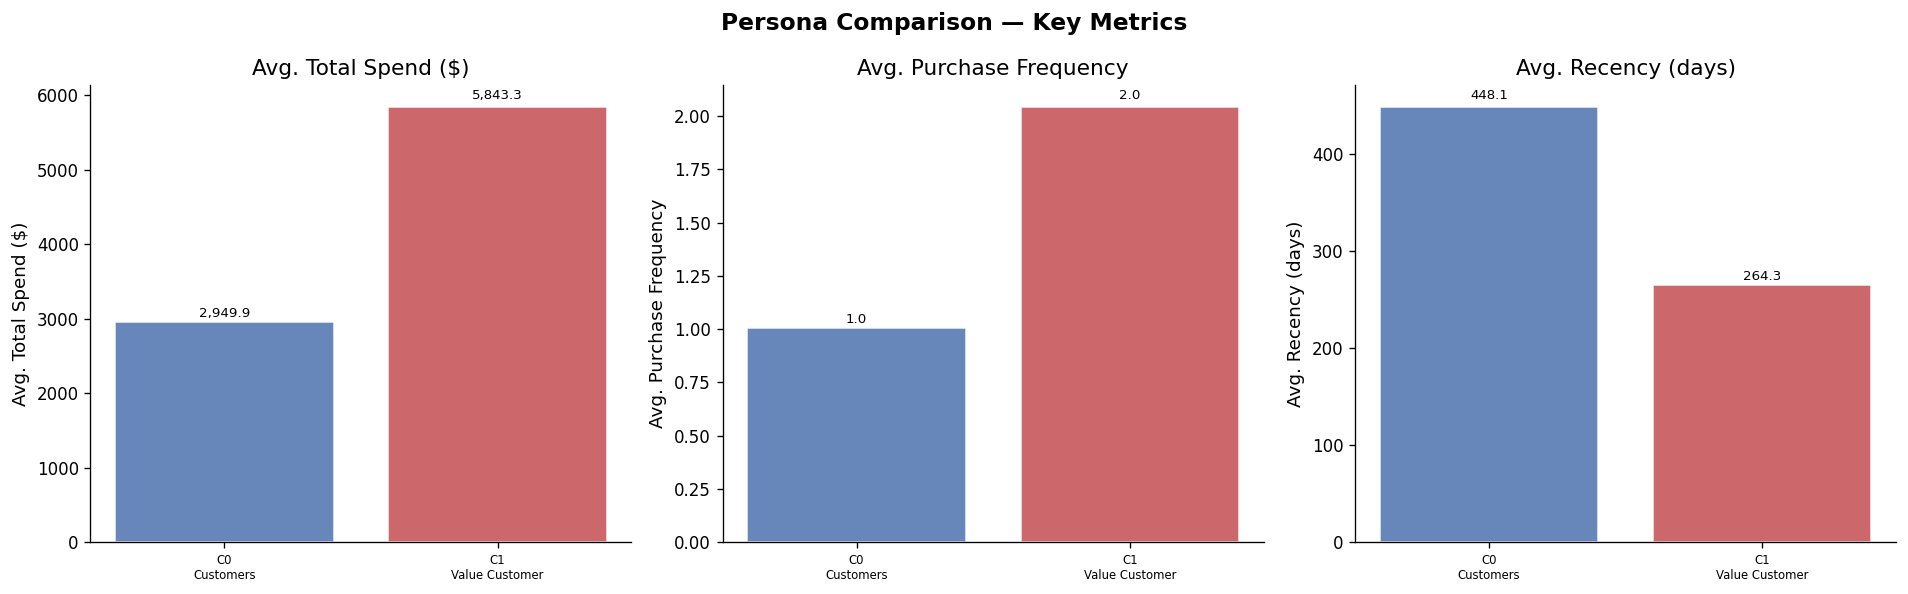

In [31]:
# ── Visualise persona summary ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Persona Comparison — Key Metrics", fontsize=14, fontweight='bold')

metrics = [('Monetary', 'Avg. Total Spend ($)'),
           ('Frequency', 'Avg. Purchase Frequency'),
           ('Recency', 'Avg. Recency (days)')]

for ax, (metric, label) in zip(axes, metrics):
    vals   = [cust[cust['Cluster']==c][metric].mean() for c in range(OPTIMAL_K)]
    names  = [f"C{c}\n{persona_labels[c].split(' ',1)[1][:14]}" for c in range(OPTIMAL_K)]
    bars   = ax.bar(names, vals, color=PALETTE[:OPTIMAL_K], edgecolor='white', alpha=0.85)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.tick_params(axis='x', labelsize=7)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{val:,.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('persona_comparison.png', bbox_inches='tight')
plt.show()


## 13. Segment Deep-Dive on Original Transaction Data

We merge cluster labels back to transactions to explore behaviour patterns.


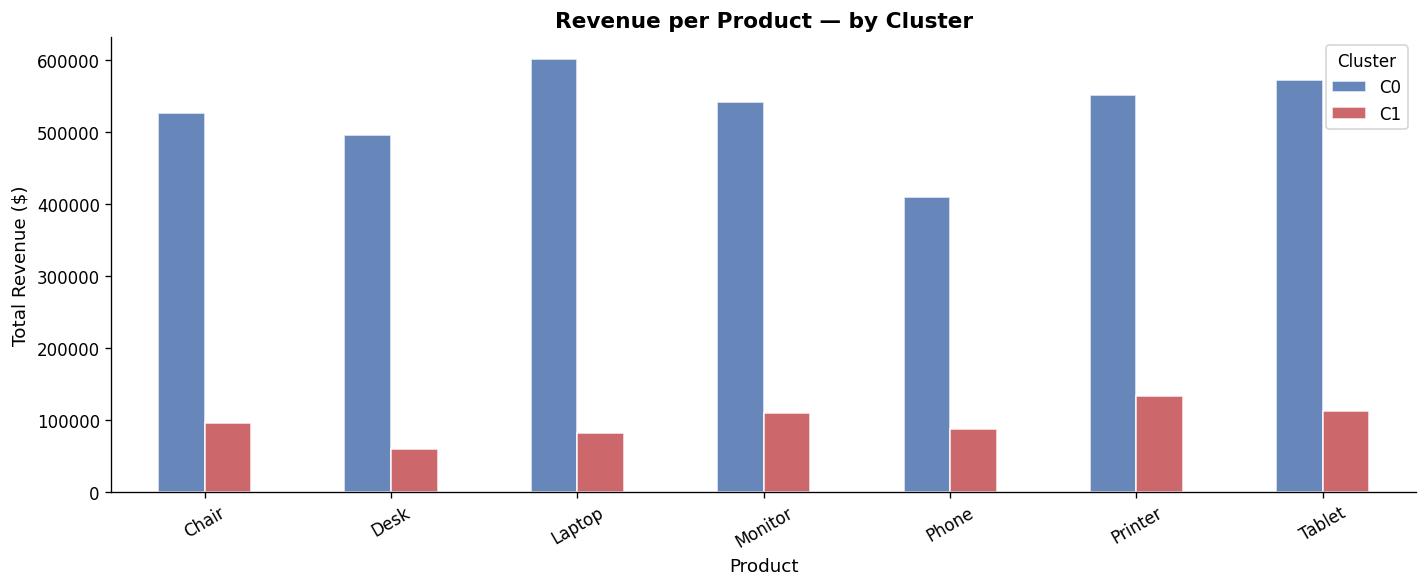

In [34]:
df_seg = df.merge(cust[['Cluster']].reset_index(), on='CustomerName', how='left')

# Product preference per cluster
prod_cluster = (df_seg.groupby(['Cluster','Product'])['TotalPrice']
                      .sum().reset_index()
                      .pivot(index='Cluster', columns='Product', values='TotalPrice')
                      .fillna(0))

fig, ax = plt.subplots(figsize=(12, 5))
prod_cluster.T.plot(kind='bar', ax=ax, color=PALETTE[:OPTIMAL_K], edgecolor='white', alpha=0.85)
ax.set_title("Revenue per Product — by Cluster", fontweight='bold')
ax.set_xlabel("Product")
ax.set_ylabel("Total Revenue ($)")
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Cluster', labels=[f'C{c}' for c in range(OPTIMAL_K)])
plt.tight_layout()
plt.savefig('product_by_cluster.png', bbox_inches='tight')
plt.show()


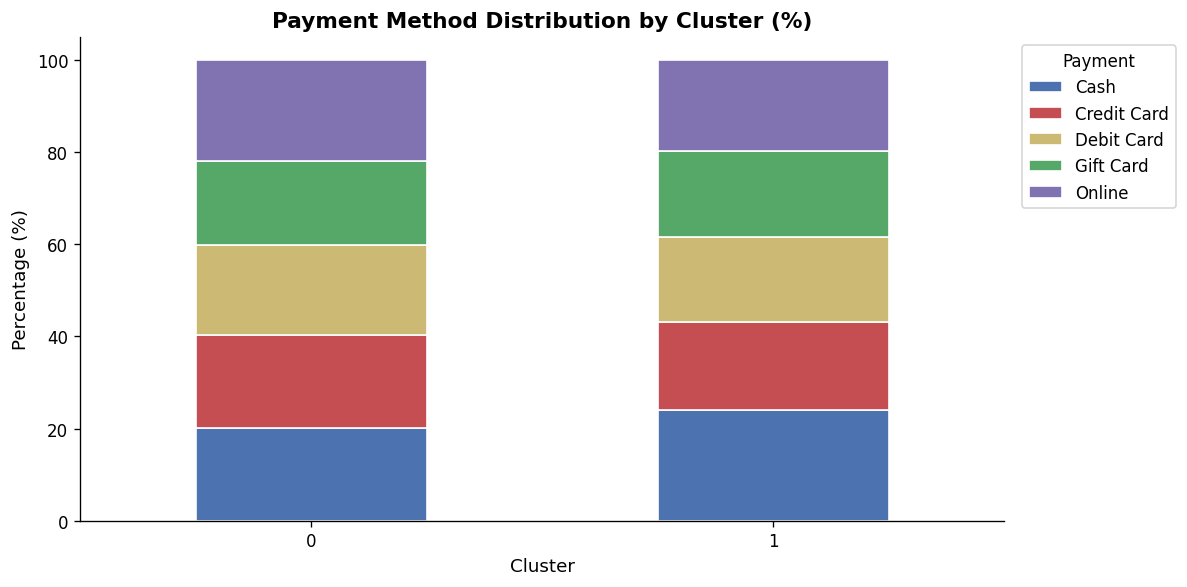

In [35]:
# Payment method mix per cluster
pay_cluster = (df_seg.groupby(['Cluster','PaymentMethod'])
                     .size().unstack(fill_value=0))
pay_pct = pay_cluster.div(pay_cluster.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
pay_pct.plot(kind='bar', ax=ax, stacked=True,
             color=['#4C72B0','#C44E52','#CCB974','#55A868','#8172B2'], edgecolor='white')
ax.set_title("Payment Method Distribution by Cluster (%)", fontweight='bold')
ax.set_xlabel("Cluster")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Payment', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig('payment_by_cluster.png', bbox_inches='tight')
plt.show()


# Conclusion & Recommendations

## Project Summary

In this project, a complete customer segmentation pipeline was developed using unsupervised machine learning techniques. Starting from data preprocessing and feature engineering, customer behavior was analyzed using RFM (Recency, Frequency, Monetary) and additional behavioral features. The data was standardized, reduced using PCA, and clustered with the K-Means algorithm to identify meaningful customer groups.

The optimal number of clusters was determined using the Elbow Method and Silhouette Score, and the resulting clusters were translated into business-friendly customer personas to support data-driven decision-making.


## Key Insights

The analysis revealed that customers exhibit different purchasing behaviors and can be grouped into distinct segments.

Some customer groups generate high revenue and should be retained through loyalty programs and personalized offers. Other groups show lower engagement or spending patterns and can be targeted through promotional campaigns, discounts, or re-engagement strategies. These insights can help businesses allocate marketing resources more effectively and improve customer retention.


## Recommendations

Based on the clustering results, the following recommendations are suggested:

- Focus on retaining high-value customers through loyalty rewards and personalized experiences.
- Re-engage inactive or low-value customers using targeted promotions and email campaigns.
- Increase sales among regular customers through product recommendations and cross-selling strategies.
- Monitor customer behavior regularly and update customer segments as purchasing patterns change.


## Future Work

The project can be further enhanced by:

- Deploying the trained PCA and K-Means pipeline for real-time customer segmentation.
- Incorporating additional customer behavior data, such as browsing history or website interactions.
- Evaluating personalized marketing campaigns using A/B testing.
- Retraining the clustering model periodically to reflect changing customer behavior.
- Comparing K-Means with other clustering techniques such as DBSCAN, Hierarchical Clustering, or Gaussian Mixture Models.



This project demonstrates how customer segmentation can transform raw transactional data into meaningful business insights, enabling organizations to make more informed marketing and customer relationship decisions through data-driven strategies.

In [39]:
print("=" * 60)
print("  PROJECT 3 — UNSUPERVISED LEARNING: CUSTOMER SEGMENTATION")
print("=" * 60)
print()
print(f"  Dataset           : 1,500 transactions × 19 features")
print(f"  Customer profiles : {len(cust):,}")
print(f"  Features used     : {len(feature_cols)}")
print(f"  PCA components    : {n_comp_95}  (≥95% variance)")
print(f"  Optimal K         : {OPTIMAL_K}")
print(f"  Silhouette Score  : {silhouette_score(X_pca, cust['Cluster'].values):.4f}")
print()
print("  Discovered Personas:")
for c in range(OPTIMAL_K):
    cnt = (cust['Cluster']==c).sum()
    print(f"   Cluster {c} ({cnt:3d} customers) → {persona_labels[c]}")
print()


  PROJECT 3 — UNSUPERVISED LEARNING: CUSTOMER SEGMENTATION

  Dataset           : 1,500 transactions × 19 features
  Customer profiles : 1,371
  Features used     : 14
  PCA components    : 11  (≥95% variance)
  Optimal K         : 2
  Silhouette Score  : 0.3757

  Discovered Personas:
   Cluster 0 (1255 customers) → At-Risk Customers
   Cluster 1 (116 customers) → High Value Customers

